### Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [2]:
from pathlib import Path

DATA_PATH = Path("../data/processed")
fund_master = pd.read_csv(
    DATA_PATH / "01_fund_master_clean.csv"
)
nav_history = pd.read_csv(
    DATA_PATH / "02_nav_history_clean.csv"
)
aum = pd.read_csv(
    DATA_PATH / "03_aum_by_fund_house_clean.csv"
)
sip = pd.read_csv(
    DATA_PATH / "04_monthly_sip_inflows_clean.csv"
)
category_flow = pd.read_csv(
    DATA_PATH / "05_category_inflows_clean.csv"
)
folio = pd.read_csv(
    DATA_PATH / "06_industry_folio_count_clean.csv"
)
performance = pd.read_csv(
    DATA_PATH / "07_scheme_performance_clean.csv"
)
transactions = pd.read_csv(
    DATA_PATH / "08_investor_transactions_clean.csv"
)
holdings = pd.read_csv(
    DATA_PATH / "09_portfolio_holdings_clean.csv"
)

### NAV Trend Analysis

In [12]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022-2026)"
)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)
fig.add_vrect(
    x0="2024-07-01",
    x1="2024-10-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white",
    legend_title="AMFI Code",
    height=700
)
fig.show()


Insight 1:
Most schemes showed a strong upward NAV trend during the 2023 bull market, while several funds experienced temporary declines during the 2024 market correction period.

### Aum Analysis

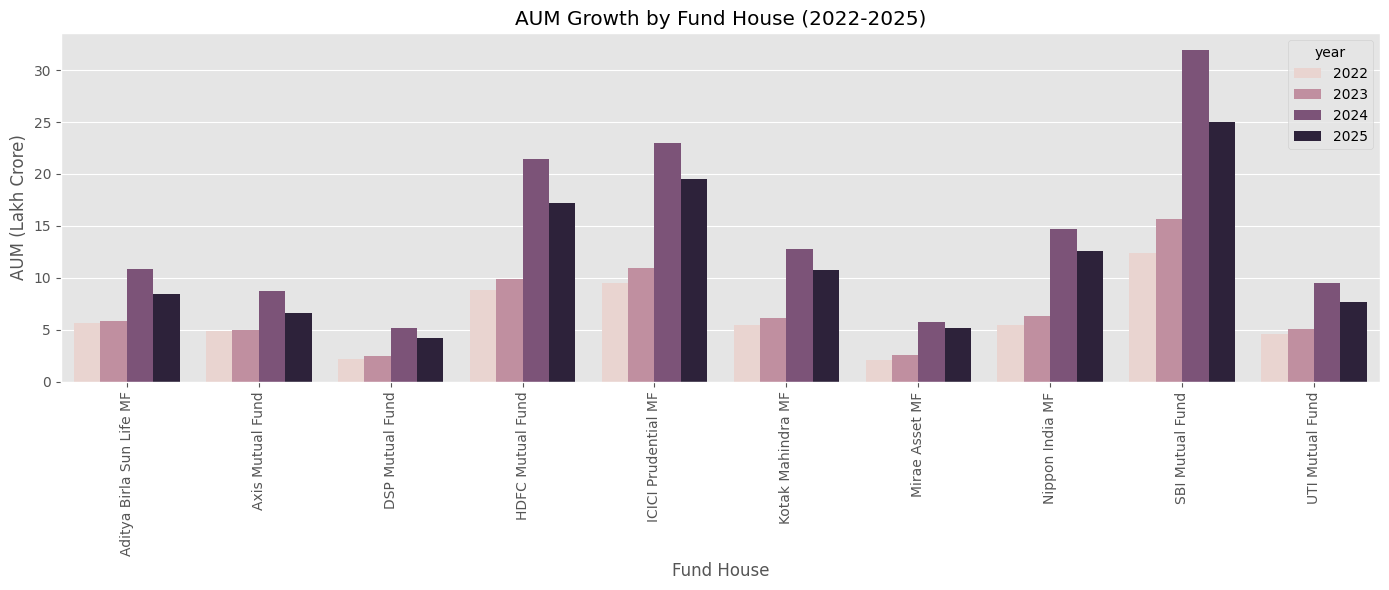

In [13]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
aum_yearly = (
    aum.groupby(
        ["year", "fund_house"],
        as_index=False
    )["aum_lakh_crore"]
    .sum()
)
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


In [14]:
aum_yearly["fund_house"].unique()

<StringArray>
['Aditya Birla Sun Life MF',         'Axis Mutual Fund',
          'DSP Mutual Fund',         'HDFC Mutual Fund',
      'ICICI Prudential MF',        'Kotak Mahindra MF',
           'Mirae Asset MF',          'Nippon India MF',
          'SBI Mutual Fund',          'UTI Mutual Fund']
Length: 10, dtype: str

In [15]:
sbi_data = aum_yearly[
    aum_yearly["fund_house"] == "SBI Mutual Fund"
]

print(sbi_data)

    year       fund_house  aum_lakh_crore
8   2022  SBI Mutual Fund           12.35
18  2023  SBI Mutual Fund           15.62
28  2024  SBI Mutual Fund           31.94
38  2025  SBI Mutual Fund           25.00


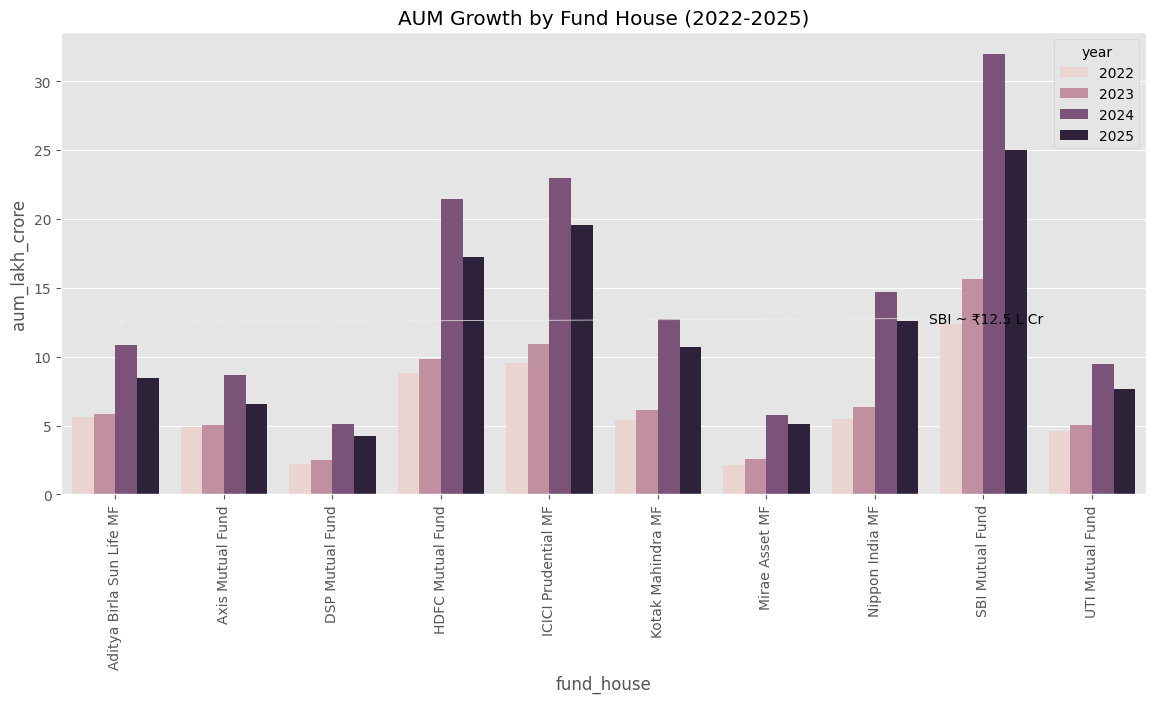

In [20]:
plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.xticks(rotation=90)

plt.title(
    "AUM Growth by Fund House (2022-2025)"
)

plt.annotate(
    "SBI ~ ₹12.5 L Cr",
    xy=(0,12.5),
    xytext=(7.5,12.5),
    arrowprops=dict(arrowstyle="->")
)

plt.show()

Insight 2:
SBI Mutual Fund maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore and demonstrating strong market leadership during the period.

### SIP Analysis

In [21]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white"
)

fig.show()

Insight 3:
Monthly SIP inflows showed a strong upward trend throughout the study period, reaching an all-time high of ₹31,002 crore in December 2025, reflecting growing retail investor participation in mutual funds.

### Category Inflow Analysis

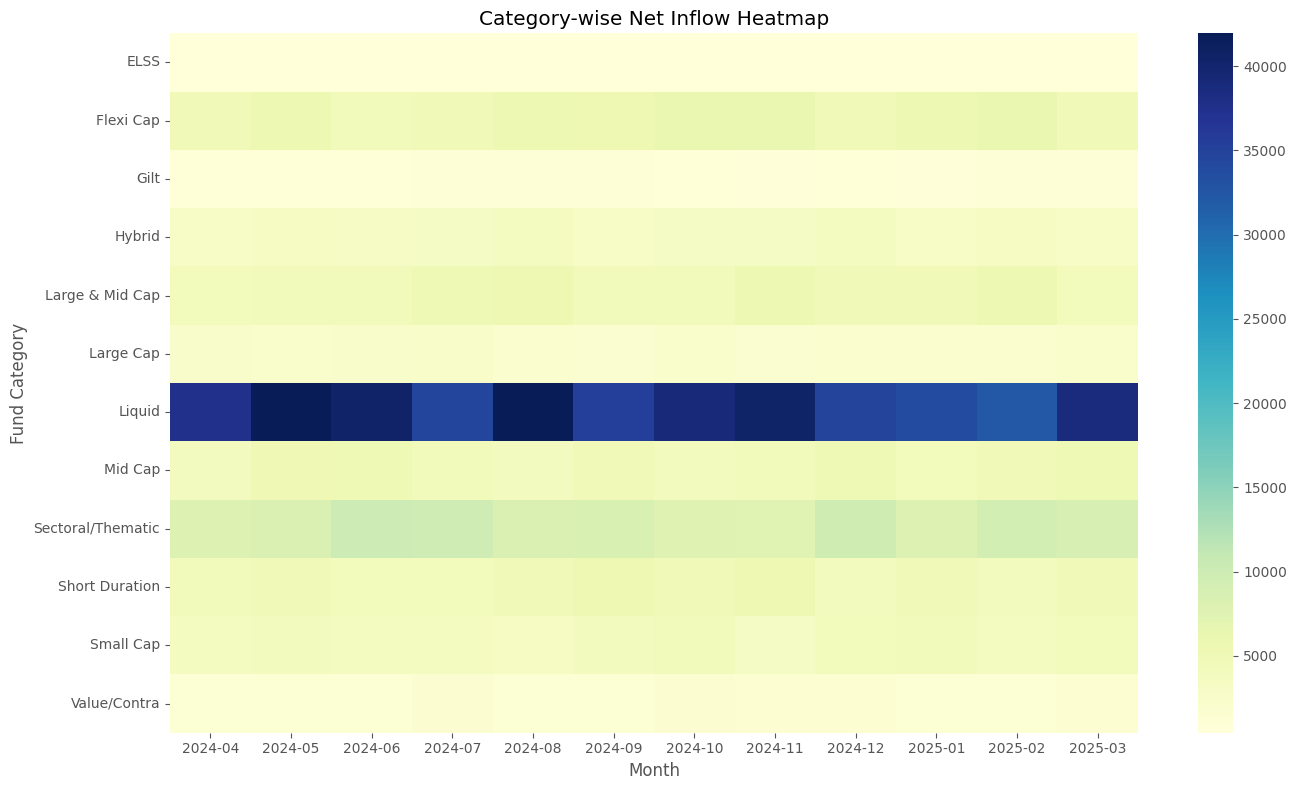

In [22]:
heatmap_data = category_flow.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title(
    "Category-wise Net Inflow Heatmap"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

Insight 4:
Net inflows varied significantly across fund categories, with certain categories consistently attracting higher investor interest while others experienced periods of weak or negative flows.

### Investor Demographics

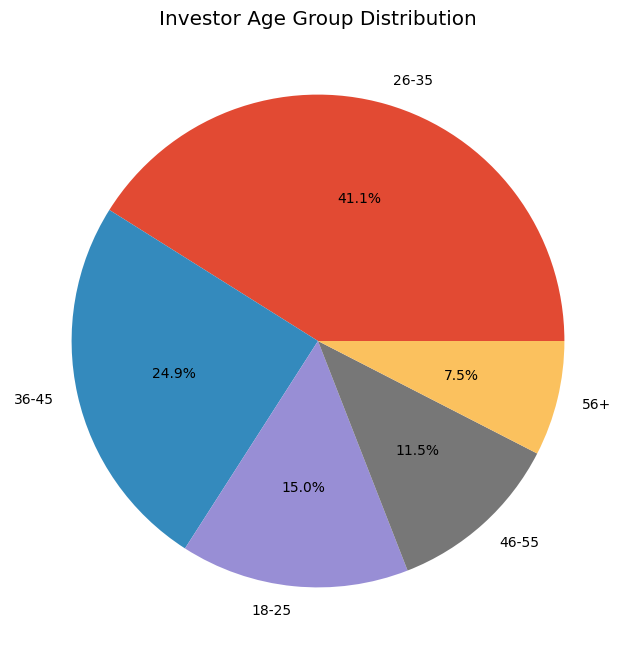

In [23]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.ylabel("")

plt.show()

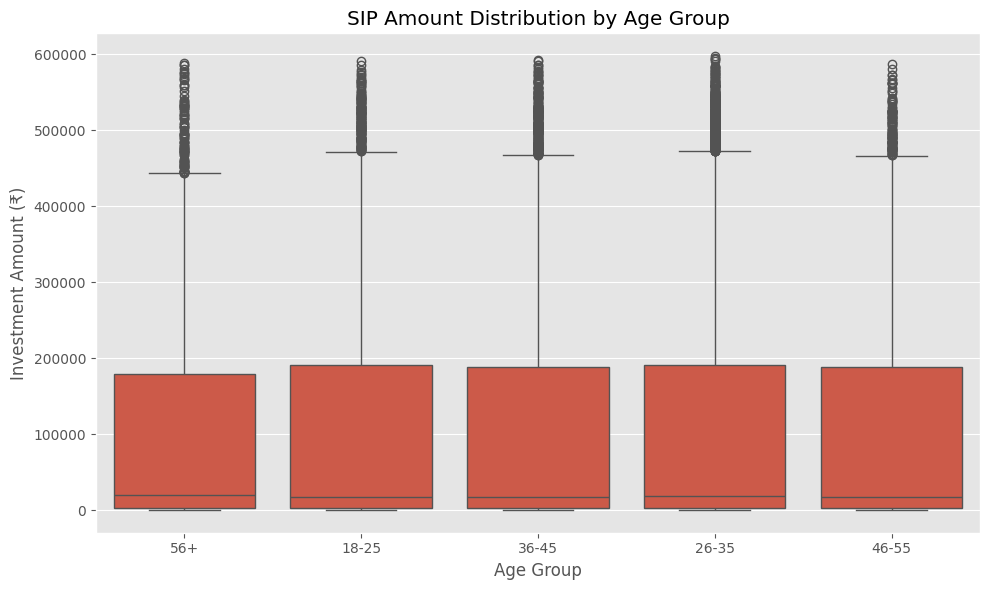

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.show()

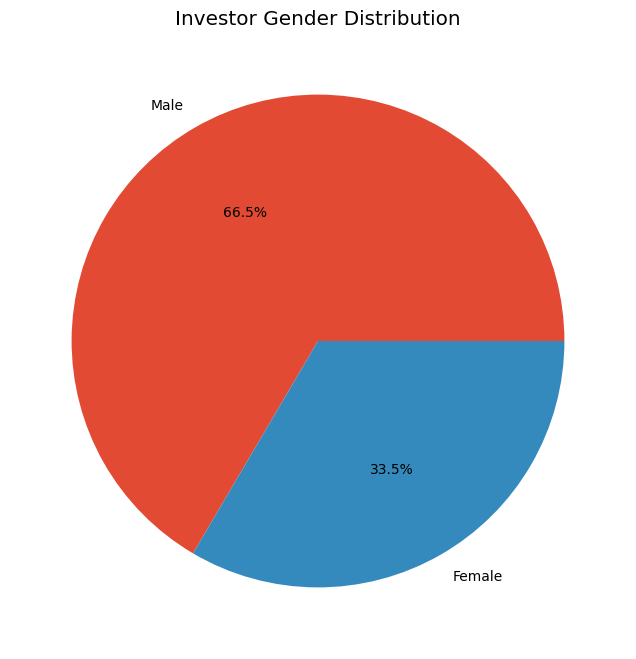

In [25]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.ylabel("")

plt.show()

Insight 5:
The majority of investors belonged to the middle-age groups, indicating stronger participation from working professionals.

Insight 6:
Investment amounts varied across age groups, with older investors generally contributing larger SIP amounts.

Insight 7:
The investor base showed a noticeable gender imbalance, highlighting differences in mutual fund participation across genders.

### Geographic Analysis

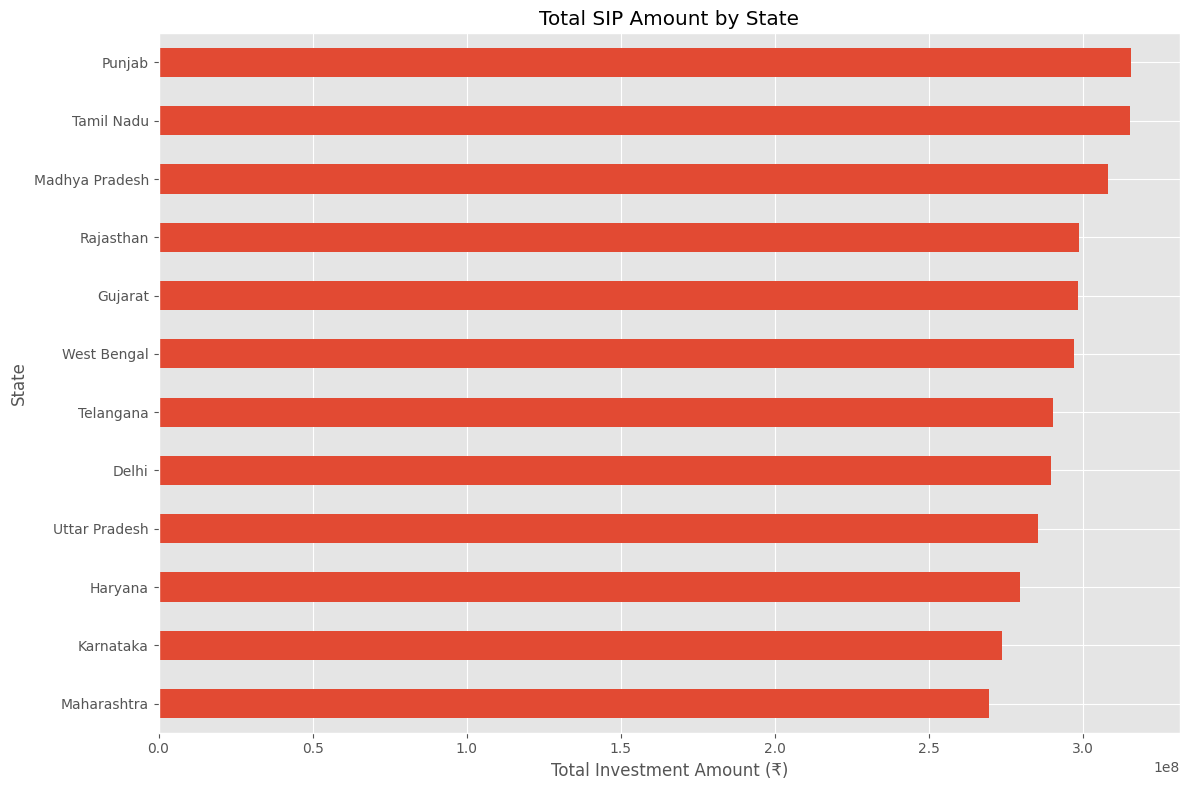

In [26]:
state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)
plt.figure(figsize=(12,8))

state_sip.plot(
    kind="barh"
)

plt.title(
    "Total SIP Amount by State"
)

plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

In [27]:
transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

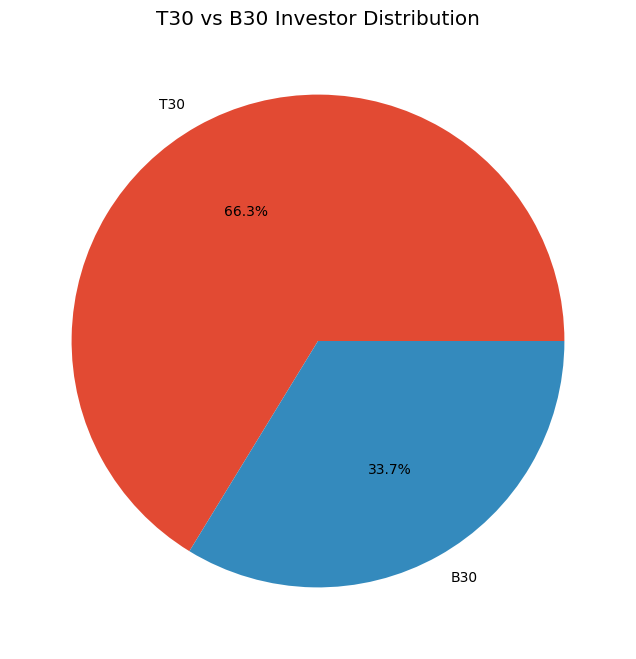

In [28]:
plt.figure(figsize=(8,8))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investor Distribution"
)

plt.ylabel("")

plt.show()

Insight 8:
Investor participation was concentrated in a few key states, indicating stronger mutual fund adoption in economically active regions.

Insight 9:
T30 cities contributed a larger share of investments, although B30 cities showed meaningful participation, highlighting the growing penetration of mutual funds beyond major metropolitan areas.

###  Folio Growth Analysis

In [29]:
folio["month"] = pd.to_datetime(
    folio["month"]
)
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022-2025)"
)
fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr Folios",
    showarrow=True,
    arrowhead=2
)
fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr Folios",
    showarrow=True,
    arrowhead=2
)
fig.add_annotation(
    x="2024-01-01",
    y=20,
    text="Crossed 20 Cr Folios",
    showarrow=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    template="plotly_white"
)

fig.show()

Insight 10:
The total number of mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating rapid growth in retail investor participation.

### Correlation Analysis

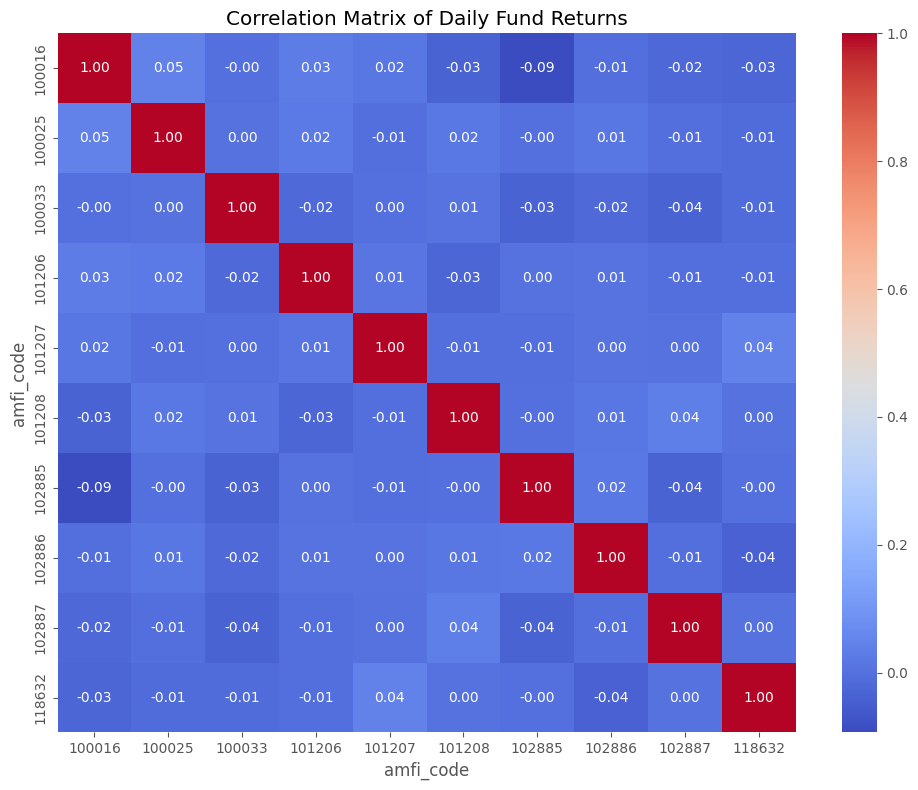

In [30]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

selected_funds = (
    nav_history["amfi_code"]
    .unique()[:10]
)

nav_subset = nav_history[
    nav_history["amfi_code"].isin(
        selected_funds
    )
]
nav_matrix = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = nav_matrix.pct_change()
corr_matrix = daily_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Daily Fund Returns"
)

plt.tight_layout()

plt.show()

Insight 11:
Most large-cap funds exhibited strong positive correlations in daily returns, indicating similar responses to broader market movements and economic conditions.

### Sector Allocation Analysis

In [31]:
sector_allocation = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)
sector_allocation.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

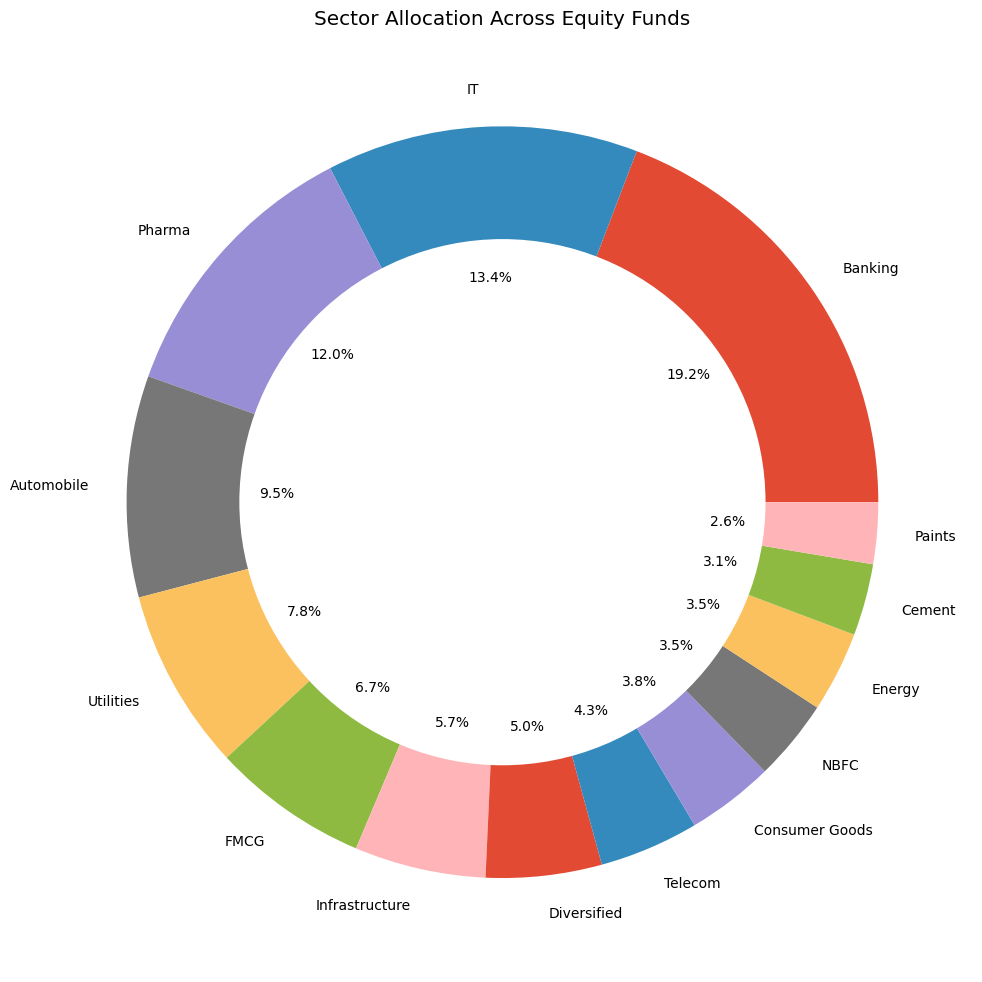

In [32]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.tight_layout()

plt.show()

Insight 12:
Portfolio allocations were concentrated in a few dominant sectors such as Financial Services, Information Technology, and Healthcare, reflecting the preference of equity funds for large and stable sectors of the economy.

### Key Findings

1. NAV values across most mutual fund schemes showed a consistent upward trend between 2022 and 2025, with particularly strong growth observed during the 2023 bull market period.
2. SBI Mutual Fund maintained the highest Assets Under Management (AUM), highlighting its dominant position in the Indian mutual fund industry.
3. Monthly SIP inflows increased steadily throughout the analysis period and reached an all-time high of ₹31,002 crore in December 2025, reflecting growing retail investor participation.
4. Investor inflows varied significantly across fund categories, indicating changing investor preferences and market sentiment over time.
5. The majority of investors belonged to the working-age population, suggesting that salaried and mid-career individuals form the core mutual fund investor base.
6. Higher age groups generally exhibited larger investment amounts, indicating greater investment capacity and financial stability among experienced investors.
7. A noticeable gender imbalance was observed in mutual fund participation, with one gender contributing a larger share of total investments.
8. Investment activity was concentrated in a few major states, demonstrating stronger mutual fund penetration in economically developed regions.
9. While T30 cities contributed a significant portion of investments, B30 cities also showed substantial participation, indicating the expanding reach of mutual funds beyond metropolitan areas.
10. The total number of mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting rapid growth in investor adoption.